In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 40

In [2]:

processed_dir = "../data/processed"

X_train = pd.read_csv(f"{processed_dir}/X_train_raw.csv")
X_test = pd.read_csv(f"{processed_dir}/X_test_raw.csv")
y_train = pd.read_csv(f"{processed_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_dir}/y_test.csv").squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5861, 8) | Test: (1466, 8)


In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",40
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    cv_scores[metric] = scores
    print(f"{metric:10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

accuracy  : 0.9126 (+/- 0.0038)
precision : 0.8636 (+/- 0.0052)
recall    : 0.9108 (+/- 0.0123)
f1        : 0.8865 (+/- 0.0055)
roc_auc   : 0.9680 (+/- 0.0019)


In [5]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV roc_auc:", grid_search.best_score_)

rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 400}
Best CV roc_auc: 0.9689235284661762


In [6]:
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

accuracy  : 0.9168
precision : 0.8506
recall    : 0.9435
f1        : 0.8946
roc_auc   : 0.9712


In [7]:
print(classification_report(y_test, y_pred, target_names=["FALSE POSITIVE", "CONFIRMED"]))

                precision    recall  f1-score   support

FALSE POSITIVE       0.96      0.90      0.93       917
     CONFIRMED       0.85      0.94      0.89       549

      accuracy                           0.92      1466
     macro avg       0.91      0.92      0.91      1466
  weighted avg       0.92      0.92      0.92      1466



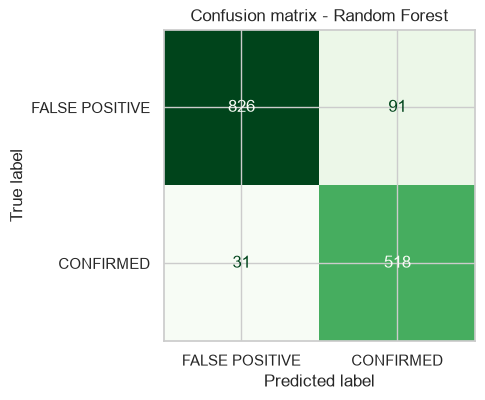

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FALSE POSITIVE", "CONFIRMED"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("Confusion matrix - Random Forest")
plt.tight_layout()
plt.show()

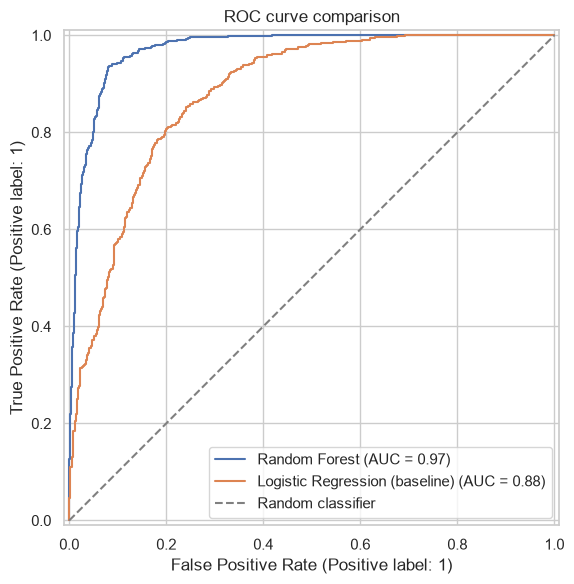

In [9]:
import joblib

log_reg = joblib.load("../models/baseline_logistic_regression.joblib")
X_test_scaled = pd.read_csv(f"{processed_dir}/X_test.csv")
y_proba_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, ax=ax, name="Logistic Regression (baseline)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("ROC curve comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_best.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
4,koi_prad,0.255715
7,koi_model_snr,0.175409
0,koi_period,0.115457
3,koi_impact,0.103945
6,koi_insol,0.097994
2,koi_depth,0.090401
1,koi_duration,0.082561
5,koi_teq,0.078518


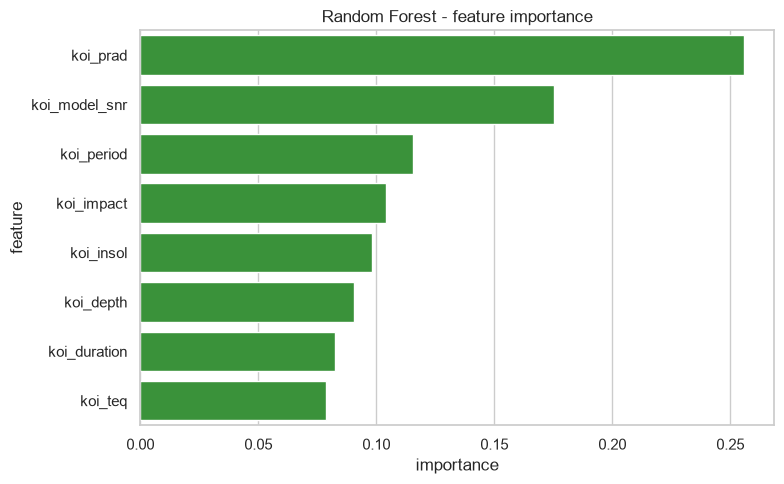

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="#2ca02c")
plt.title("Random Forest - feature importance")
plt.tight_layout()
plt.show()

In [12]:
errors = X_test.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors["y_proba"] = y_proba
errors["is_error"] = errors["y_true"] != errors["y_pred"]
errors["confidence"] = np.where(errors["y_pred"] == 1, errors["y_proba"], 1 - errors["y_proba"])

print(f"Number of errors: {errors['is_error'].sum()} / {len(errors)} ({errors['is_error'].mean()*100:.2f}%)")

worst_errors = errors[errors["is_error"]].sort_values("confidence", ascending=False)
worst_errors.head(10)

Number of errors: 122 / 1466 (8.32%)


,koi_period,koi_duration,koi_depth,koi_impact,koi_prad,koi_teq,koi_insol,koi_model_snr,y_true,y_pred,y_proba,is_error,confidence
856,10.161048,3.0448,908.9,0.031,2.72,800.0,96.98,36.8,0,1,0.991405,True,0.991405
872,20.719272,4.0388,224.6,0.744,2.51,818.0,105.78,36.0,0,1,0.979978,True,0.979978
703,13.542041,3.3340,338.7,0.722,2.01,794.0,93.98,26.4,0,1,0.977933,True,0.977933
486,10.804872,2.7215,292.7,0.207,1.71,857.0,127.84,27.4,0,1,0.974708,True,0.974708
846,14.170987,3.4804,3070.8,0.041,4.19,608.0,32.22,93.6,0,1,0.970863,True,0.970863
698,8.412007,3.9230,819.6,0.022,1.71,590.0,28.69,39.7,0,1,0.960309,True,0.960309
253,13.616455,5.1750,376.1,1.190,22.29,755.0,76.81,22.6,1,0,0.041563,True,0.958438
291,13.262554,4.6500,916.4,0.943,3.55,766.0,81.56,31.4,0,1,0.958187,True,0.958187
918,88.180468,5.0330,1138.6,0.026,2.78,359.0,3.94,17.5,0,1,0.955420,True,0.955420
995,6.717256,2.5207,272.7,0.163,2.78,1264.0,603.71,49.1,0,1,0.949862,True,0.949862


In [14]:
from pathlib import Path

models_dir = Path("../models")
joblib.dump(rf_best, models_dir / "random_forest.joblib")

results_summary = pd.read_csv(models_dir / "baseline_results.csv")

new_row = pd.DataFrame([{
    "model": "RandomForest (tuned)",
    **metrics
}])

results_summary = pd.concat([results_summary, new_row], ignore_index=True)
results_summary.to_csv(models_dir / "baseline_results.csv", index=False)


results_summary

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (baseline),0.77558,0.645503,0.888889,0.747893,0.879960
1,RandomForest (tuned),0.91678,0.850575,0.943534,0.894646,0.971234
